# 05. Threshold Economics and a Locked Test

**Project:** Customer Churn Prediction & Lifetime Value.

**Source material:** Fabio Oliveira, *"Your Churn Threshold Is a Pricing Decision"*
(Towards Data Science). The article's core argument, and the reason this whole notebook
exists: a default 0.5 classification threshold implicitly assumes a false positive (a
wasted retention offer) costs exactly as much as a false negative (a missed churner).
That's almost never true, so the article proposes pricing both error types in real
currency, sweeping the threshold, and picking whichever one minimizes total dollar cost
-- with a closed-form shortcut, `t* = FP/(FP+FN)`, offered as a check against the
brute-force sweep. Section 2 below runs that closed-form check directly.

**This notebook covers:**
1. A quick methodological check against the source article's own flat-cost exercise,
   before this notebook's segment-aware framework replaces it
2. Turning illustrative per-segment intervention costs into a single decision-loss
   objective
3. Selecting a model and a global probability threshold **on validation only**
4. Checking who actually bears the assumed cost, and how sensitive the choice is to the
   underlying price assumptions
5. Freezing that choice and evaluating it **exactly once** on test

**Question:** which churn model and threshold minimize a prespecified, illustrative
decision loss? Decision loss here is defined as (false positives x assumed segment
action price) + (false negatives x the conditional-active spend proxy from notebook 3,
at an assumed 25% margin). This is a reproducible accounting exercise built on stated
assumptions -- it is explicitly *not* a measurement of what any real outreach campaign
would actually save, because no real cost, response-rate, or acquisition data exists for
this dataset.

The first iteration's version of this notebook had two flaws the post-mortem called
out directly: the threshold was chosen and scored on the *same* population (no
held-out check at all), and it never asked whether 0.03 was still the right cutpoint
once costs started varying by segment. Both are fixed here by construction -- validation
selects, test only evaluates, once.

### Import necessary libraries

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

## Explicit intervention prices and the decision-loss objective

Every price below is a stated assumption, written down here so the resulting threshold
choice is reproducible and reviewable rather than buried in a formula. There's no real
campaign-cost data behind any of these numbers -- they're illustrative, scaled roughly
by how much attention a segment plausibly warrants.

**Two deliberate departures from Oliveira's own setup, both forced by what this
dataset doesn't have.**

Oliveira prices a false negative as `CAC + ARPU x remaining_tenure` -- a subscription
business's cost of losing a paying customer. This dataset has no acquisition-cost field
and no recurring-subscription structure to compute a remaining-tenure figure from, so
that formula doesn't transfer. In its place, false-negative cost here is notebook 3's
**conditional-active spend proxy** (predicted revenue *if* the customer buys again,
margin-adjusted at 25%) -- the same role in the arithmetic, a genuinely different
quantity underneath it. Munro's "From Probabilistic to Predictive: CLV"  would
normally supply this kind of forward-looking spend estimate via BG-NBD/Gamma-Gamma;
notebook 3 explains why that technique fails outright on this population and why the
conditional-active ML model stands in for it instead.

Oliveira also prices every false positive at one flat figure, and names segment-aware
FP pricing as the article's own explicit next step -- worth doing, not yet done there.
That's exactly what the `INTERVENTIONS` table below does: nine segment-specific prices
instead of one flat number, built and used from the start rather than deferred to a
later notebook.

In [3]:
INTERVENTIONS = {
    "Champions":                    ("Loyalty/bundle upgrade, dedicated outreach", 40.),
    "Churn Risk (high value)":      ("Proactive outreach", 35.),
    "Loyal Customers":              ("Personalized email and modest incentive", 20.),
    "Potential Loyalists":          ("Standard discount code", 15.),
    "At Risk":                      ("Discount and re-engagement email", 15.),
    "Recent, Low Engagement":       ("Light nudge email", 8.),
    "Needs Attention":              ("Light nudge email", 8.),
    "Lost / Lowest Priority":       ("Automated low-cost email", 5.),
    "High-Value Infrequent Buyers": ("Standard discount code", 15.),
}
pd.DataFrame({seg: {"intervention": action, "price_gbp": cost}
             for seg, (action, cost) in INTERVENTIONS.items()}).T

,intervention,price_gbp
Champions,"Loyalty/bundle upgrade, dedicated outreach",40.0
Churn Risk (high value),Proactive outreach,35.0
Loyal Customers,Personalized email and modest incentive,20.0
Potential Loyalists,Standard discount code,15.0
At Risk,Discount and re-engagement email,15.0
"Recent, Low Engagement",Light nudge email,8.0
Needs Attention,Light nudge email,8.0
Lost / Lowest Priority,Automated low-cost email,5.0
High-Value Infrequent Buyers,Standard discount code,15.0


**The decision-loss function.** For a given model, threshold, and cost basis:

- A **false positive** (flagged, didn't actually churn) costs either a flat £15 (the
  `flat` cost basis, kept as a comparator) or that customer's segment-specific action
  price (the `segment` basis).
- A **false negative** (not flagged, actually churned) costs the conditional-active
  spend proxy from notebook 3, scaled by the assumed 25% margin -- this is the same
  `fn_cost_illustrative` column exported there.
- **Intervention spend** is tracked separately: the action price for *every* flagged
  customer, whether or not they were actually a churner. This is a different number
  from the false-positive cost component -- FP cost only counts flagged non-churners,
  while total spend counts everyone flagged.

In [4]:
def add_interventions(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    missing = set(out["segment"].dropna()) - set(INTERVENTIONS)
    assert not missing and not out["segment"].isna().any(), f"missing intervention mapping: {missing}"
    out["intervention"] = out["segment"].map(lambda s: INTERVENTIONS[s][0])
    out["action_cost"] = out["segment"].map(lambda s: INTERVENTIONS[s][1]).astype(float)
    return out

def price(df: pd.DataFrame, threshold: float, proba_col: str, *, flat: bool = False,
         margin_multiplier: float = 1.0, action_multiplier: float = 1.0):
    """Score one fully specified rule. The observed label is used only to grade the
    rule after the fact -- never to decide who gets flagged."""
    z = df.copy()
    z["flagged"] = z[proba_col].ge(threshold).astype(int)
    z["is_fp"] = z["flagged"].eq(1) & z["churned"].eq(0)
    z["is_fn"] = z["flagged"].eq(0) & z["churned"].eq(1)
    unit_fp_cost = 15.0 if flat else z["action_cost"]
    z["fp_loss"] = z["is_fp"] * unit_fp_cost * action_multiplier
    z["fn_loss"] = z["is_fn"] * z["fn_cost_illustrative"] * margin_multiplier
    z["intervention_spend"] = z["flagged"] * z["action_cost"] * action_multiplier
    z["decision_loss"] = z["fp_loss"] + z["fn_loss"]
    result = {"n": len(z), "flagged": int(z["flagged"].sum()), "fp": int(z["is_fp"].sum()),
              "fn": int(z["is_fn"].sum()), "fp_loss": float(z["fp_loss"].sum()),
              "fn_loss": float(z["fn_loss"].sum()), "decision_loss": float(z["decision_loss"].sum()),
              "all_flagged_spend": float(z["intervention_spend"].sum())}
    return result, z

def grid_search(df: pd.DataFrame, proba_col: str, *, flat: bool = False,
                margin_multiplier: float = 1.0, action_multiplier: float = 1.0) -> pd.DataFrame:
    grid = np.r_[0.0, np.arange(0.01, 1.0, 0.01), 1.01]
    rows = [{"threshold": float(t),
            **price(df, float(t), proba_col, flat=flat,
                    margin_multiplier=margin_multiplier, action_multiplier=action_multiplier)[0]}
           for t in grid]
    return pd.DataFrame(rows)

## 1. Join the churn probabilities and the CLV cost proxy

In [5]:
churn = pd.read_parquet(PROCESSED_DATA / "retail_churn_probabilities.parquet")
clv = pd.read_parquet(PROCESSED_DATA / "retail_clv_policy_inputs.parquet")

assert churn["CustomerID"].is_unique and clv["CustomerID"].is_unique
assert set(churn["CustomerID"]) == set(clv["CustomerID"])

decisions = churn.merge(clv.drop(columns=["segment"]), on=["CustomerID", "split"], validate="one_to_one")
decisions = add_interventions(decisions)
assert decisions["fn_cost_illustrative"].ge(0).all()

validation = decisions.loc[decisions["split"].eq("validation")].copy()
print(f"Validation n: {len(validation)}   Test n (reserved): {(decisions['split'].eq('test')).sum()}")

Validation n: 385   Test n (reserved): 386


## 2. A quick check: does Oliveira's closed-form threshold work here?

Before building this notebook's segment-aware framework, it's worth running the
simpler exercise the source article actually describes: a single flat false-positive
price (£15, one retention touch) against each customer's own predicted false-negative
cost, with the threshold picked two ways -- a brute-force sweep, and the article's own
closed-form formula, `t* = FP / (FP + FN)`. This mirrors iteration 1's version of this
notebook closely, with one real difference worth flagging up front: iteration 1's FN
cost came from BG-NBD/Gamma-Gamma (with a small ML fallback for the handful of
customers it couldn't fit). Here, BG-NBD/Gamma-Gamma fails outright for this
population -- notebook 3's `q <= 1` gate -- so FN cost comes entirely from the
conditional-active ML proxy instead. Same role in the formula, a different model
underneath it; worth remembering if these numbers don't match iteration 1's.

The formula needs a single FN cost, not a per-customer one, so -- exactly as in
iteration 1 -- it's applied here using the **mean** FN cost across validation. That's
an approximation of an approximation: the formula itself assumes well-calibrated
probabilities, and collapsing per-customer costs to their mean discards real variation
the sweep doesn't have to discard.

In [6]:
FP_COST_FLAT = 15.0  # GBP, the article's own flat retention-touch assumption

curves = {}
for model in ["lr", "gbc"]:
    curve = grid_search(validation, f"proba_{model}", flat=True)
    curve["model"] = model
    curve["cost_basis"] = "flat"
    curves[model, "flat"] = curve

mean_fn_cost = validation["fn_cost_illustrative"].mean()
bayes_threshold = FP_COST_FLAT / (FP_COST_FLAT + mean_fn_cost)
print(f"Mean FN cost (validation): £{mean_fn_cost:.2f}")
print(f"Cost ratio at the mean (FN / FP): {mean_fn_cost / FP_COST_FLAT:.2f} : 1")
print(f"Bayes-optimal threshold (formula): {bayes_threshold:.4f}")

Mean FN cost (validation): £264.37
Cost ratio at the mean (FN / FP): 17.62 : 1
Bayes-optimal threshold (formula): 0.0537


In [7]:
for model in ["lr", "gbc"]:
    curve = curves[model, "flat"]
    empirical_best = curve.sort_values(["decision_loss", "all_flagged_spend", "threshold"],
                                       ascending=[True, True, False]).iloc[0]
    formula_result, _ = price(validation, bayes_threshold, f"proba_{model}", flat=True)
    gap = formula_result["decision_loss"] - empirical_best["decision_loss"]
    print(f"{model:4s} empirical min @ {empirical_best['threshold']:.2f} -> "
          f"£{empirical_best['decision_loss']:8.2f}   formula @ {bayes_threshold:.4f} -> "
          f"£{formula_result['decision_loss']:8.2f}   gap = £{gap:7.2f}")

lr   empirical min @ 0.17 -> £ 3413.32   formula @ 0.0537 -> £ 3495.00   gap = £  81.68
gbc  empirical min @ 0.06 -> £ 3315.00   formula @ 0.0537 -> £ 3390.00   gap = £  75.00


**The formula lands close to the sweep.** Mean FN cost on validation is
**£264.37** against the flat £15 FP price -- a 17.6:1 ratio, in the same range as
Oliveira's own 13:1 finding on a different dataset entirely, for the same underlying
reason: missing an actual churner is assumed far more expensive than one wasted
outreach touch. The formula threshold (0.0537) scores **£3,495.00** for LR and
**£3,390.00** for GBC, against empirical sweep minimums of £3,413.32 and £3,315.00 --
gaps of **£81.68** and **£75.00**, roughly 2-3% above the true minimum for both models.
That's a small, well-behaved gap, not the kind of large divergence Oliveira traced to
SMOTE-corrupted calibration in the source article. Notebook 4's decision to skip SMOTE
and `class_weight="balanced"` appears to be paying off here, in a setting the source
article itself uses as a diagnostic.

## 3. Select a model and threshold on validation only

Sweep both candidate probabilities across the full threshold range, under both the flat
comparator cost and the segment-specific cost. Pick the minimum segment-cost decision
loss; ties break toward lower assumed total spend, then a higher threshold (fewer
flags, all else equal), then LR over GBC. The flat-cost optimum is kept as a
prespecified comparator and re-scored under segment prices below, so the two bases are
compared fairly on the same footing.

In [8]:
curves = {}
for model in ["lr", "gbc"]:
    for cost_basis in ["flat", "segment"]:
        curve = grid_search(validation, f"proba_{model}", flat=(cost_basis == "flat"))
        curve["model"] = model
        curve["cost_basis"] = cost_basis
        curves[model, cost_basis] = curve

chosen = []
for (model, cost_basis), curve in curves.items():
    best = curve.sort_values(["decision_loss", "all_flagged_spend", "threshold"],
                             ascending=[True, True, False]).iloc[0]
    chosen.append(best)
choice_table = pd.DataFrame(chosen)
choice_table[["model", "cost_basis", "threshold", "n", "flagged", "fp", "fn",
             "fp_loss", "fn_loss", "decision_loss", "all_flagged_spend"]]

,model,cost_basis,threshold,n,flagged,fp,fn,fp_loss,fn_loss,decision_loss,all_flagged_spend
17,lr,flat,0.17,385,296,185,4,2775.0,638.318747,3413.318747,3356.0
17,lr,segment,0.17,385,296,185,4,2232.0,638.318747,2870.318747,3356.0
6,gbc,flat,0.06,385,336,221,0,3315.0,0.000000,3315.000000,4086.0
9,gbc,segment,0.09,385,311,197,1,2448.0,362.072757,2810.072757,3608.0


In [9]:
segment_candidates = choice_table.loc[choice_table["cost_basis"].eq("segment")].copy()
segment_candidates["model_tiebreak"] = segment_candidates["model"].map({"lr": 0, "gbc": 1})
selected = segment_candidates.sort_values(
    ["decision_loss", "all_flagged_spend", "threshold", "model_tiebreak"],
    ascending=[True, True, False, True]).iloc[0]

MODEL = str(selected["model"])
THRESHOLD = float(selected["threshold"])
print(f"LOCKED RULE: {MODEL} at threshold {THRESHOLD} -- selected on validation segment-cost loss only")

LOCKED RULE: gbc at threshold 0.09 -- selected on validation segment-cost loss only


In [10]:
flat_choice = choice_table.loc[choice_table["model"].eq(MODEL)& choice_table["cost_basis"].eq("flat")].iloc[0]

rows = []
for label, threshold in [
    ("Flat-selected threshold", float(flat_choice["threshold"])),
    ("Segment-selected threshold", THRESHOLD),
]:
    result, _ = price(validation, threshold, f"proba_{MODEL}")
    rows.append({"rule": label, "model": MODEL.upper(),
                 "threshold": threshold, **result})

comparison = pd.DataFrame(rows)
display(
    comparison.style
    .format({
        "threshold": "{:.2f}",
        "fp_loss": "£{:,.2f}",
        "fn_loss": "£{:,.2f}",
        "decision_loss": "£{:,.2f}",
        "all_flagged_spend": "£{:,.2f}",
    })
    .hide(axis="index")
)

rule,model,threshold,n,flagged,fp,fn,fp_loss,fn_loss,decision_loss,all_flagged_spend
Flat-selected threshold,GBC,0.06,385,336,221,0,"£2,906.00",£0.00,"£2,906.00","£4,086.00"
Segment-selected threshold,GBC,0.09,385,311,197,1,"£2,448.00",£362.07,"£2,810.07","£3,608.00"


GBC at **0.09** achieves segment-price loss **£2,810.07** -- lower than the same
model's flat-cost-optimal threshold of **0.06**, which scores **£2,906.00** once
re-evaluated under segment prices. This confirms the post-mortem's point directly:
picking a threshold under a flat cost assumption and then applying segment-aware prices
afterward is not the same as optimizing for segment-aware prices from the start; the
two do give different answers here, and the locked rule uses the one that's actually
optimized against the cost basis in use.

At 0.09, the rule flags **311 of 385** validation customers, including nearly everyone who actually churned. That leaves only one false negative. The tradeoff is 197 false positives: many flagged customers went on to purchase.

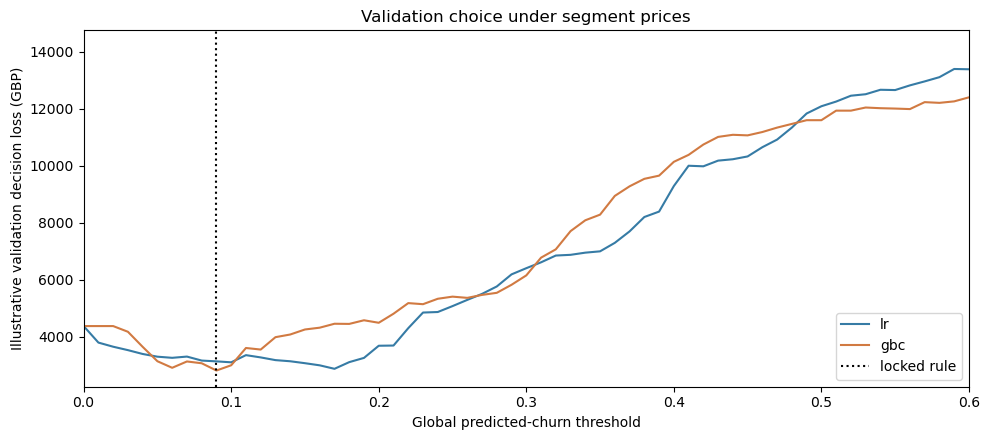

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, color in [("lr", "#367ba5"), ("gbc", "#d17a42")]:
    curve = curves[name, "segment"]
    ax.plot(curve["threshold"], curve["decision_loss"], label=name, color=color)
ax.axvline(THRESHOLD, color="black", linestyle=":", label="locked rule")
ax.set(xlim=(0, 0.6), xlabel="Global predicted-churn threshold",
       ylabel="Illustrative validation decision loss (GBP)", title="Validation choice under segment prices")
ax.legend(); fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the cost curve.** Loss rises sharply past the minimum because more
actual churners get missed under the assumed false-negative proxy, and that proxy is
large relative to any single false-positive price. GBC's minimum (**£2,810.07 at 0.09**)
and LR's (**£2,870.32 at 0.17**) are close enough that the exact winner depends on the
specific price and margin assumptions -- this curve is a selection device built on
stated assumptions, not an observed profit curve from a real campaign.

## 4. Check who actually bears the assumed cost

Total loss is one number; it's worth knowing whether it's spread evenly across
segments or concentrated in one or two. Volume and unit price both matter -- a segment
with a lot of false positives at a modest price can outweigh a segment with a high
price but few of them.

In [12]:
_, val_decisions = price(validation, THRESHOLD, f"proba_{MODEL}")
segment_audit = val_decisions.groupby("segment").agg(
    n=("CustomerID", "size"), actual_churn=("churned", "mean"), flagged=("flagged", "sum"),
    fp=("is_fp", "sum"), fn=("is_fn", "sum"), unit_cost=("action_cost", "first"),
    fp_cost=("fp_loss", "sum"), fn_cost=("fn_loss", "sum"),
    all_flagged_spend=("intervention_spend", "sum")).reset_index()
assert np.allclose(segment_audit["fp_cost"], segment_audit["fp"] * segment_audit["unit_cost"])
segment_audit.sort_values("fp_cost", ascending=False)

,segment,n,actual_churn,flagged,fp,fn,unit_cost,fp_cost,fn_cost,all_flagged_spend
5,Loyal Customers,82,0.134146,52,42,1,20.0,840.0,362.072757,1040.0
8,"Recent, Low Engagement",65,0.338462,64,42,0,8.0,336.0,0.000000,512.0
0,At Risk,29,0.344828,29,19,0,15.0,285.0,0.000000,435.0
3,High-Value Infrequent Buyers,32,0.437500,32,18,0,15.0,270.0,0.000000,480.0
6,Needs Attention,47,0.382979,47,29,0,8.0,232.0,0.000000,376.0
2,Churn Risk (high value),9,0.222222,7,5,0,35.0,175.0,0.000000,245.0
4,Lost / Lowest Priority,68,0.529412,68,32,0,5.0,160.0,0.000000,340.0
7,Potential Loyalists,27,0.074074,12,10,0,15.0,150.0,0.000000,180.0
1,Champions,26,0.000000,0,0,0,40.0,0.0,0.000000,0.0


**Reading the segment loss table.** Loyal Customers account for **£1,202.07** of
the **£2,810.07** total -- about 43% -- split between £840 in false-positive prices
(42 false positives at their £20 unit price) and a single £362.07 false-negative proxy.
That's the largest single contribution, and it's driven by *volume* as much as price:
Loyal Customers isn't the highest-priced segment (Champions and Churn Risk (high value)
are, at £40 and £35), but it has by far the most false positives of any segment at this
threshold.

In [13]:
top_losses = val_decisions.nlargest(3, "decision_loss")[["CustomerID", "segment", "decision_loss"]]
print("Top three validation decision-loss contributions:")
print(top_losses.to_string(index=False))

Top three validation decision-loss contributions:
 CustomerID                 segment  decision_loss
      17723         Loyal Customers     362.072757
      13246 Churn Risk (high value)      35.000000
      14227 Churn Risk (high value)      35.000000


Customer 17723 is the £362 false negative mentioned above, contributing far more than the next 2 largest under the selected GBC 0.09 rule.

In [14]:
exploratory = []
for segment, group in validation.groupby("segment"):
    if len(group) >= 30 and group["churned"].nunique() == 2 and group["churned"].value_counts().min() >= 8:
        curve = grid_search(group, f"proba_{MODEL}")
        best = curve.sort_values("decision_loss").iloc[0]
        exploratory.append((segment, len(group), best["threshold"], best["decision_loss"]))
print("Exploratory segment-specific thresholds (diagnostic only, not deployed):")
for row in exploratory:
    print(f"  {row[0]:32s} n={row[1]:4d}  threshold={row[2]:.2f}  loss=£{row[3]:.2f}")

Exploratory segment-specific thresholds (diagnostic only, not deployed):
  High-Value Infrequent Buyers     n=  32  threshold=0.00  loss=£270.00
  Lost / Lowest Priority           n=  68  threshold=0.31  loss=£150.00
  Loyal Customers                  n=  82  threshold=0.06  loss=£1100.00
  Needs Attention                  n=  47  threshold=0.21  loss=£184.00
  Recent, Low Engagement           n=  65  threshold=0.12  loss=£328.00


These per-segment optima are shown only as a diagnostic -- several segments are
too small (fewer than 30 customers, or fewer than 8 in either outcome class) for a
separately tuned threshold to be credible, and none of them are deployed. A single
global threshold remains the actual rule.

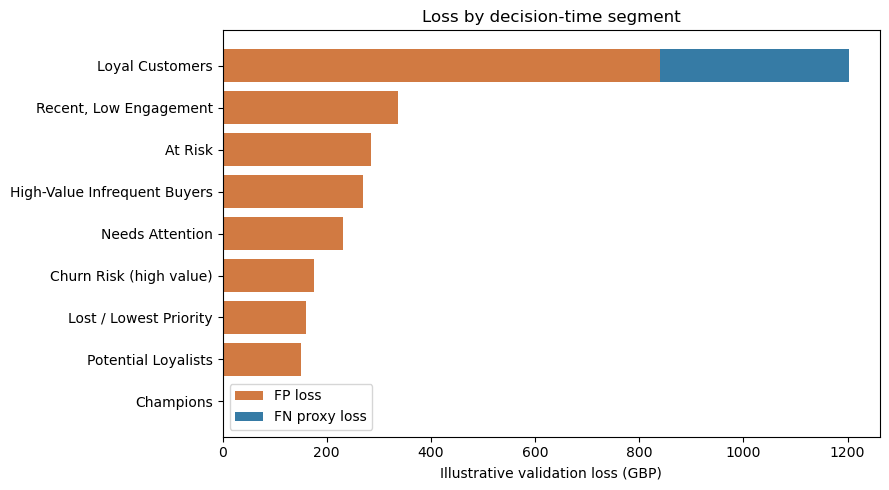

In [15]:
segment_plot = segment_audit.sort_values("fp_cost")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(segment_plot["segment"], segment_plot["fp_cost"], color="#d17a42", label="FP loss")
ax.barh(segment_plot["segment"], segment_plot["fn_cost"], left=segment_plot["fp_cost"],
       color="#367ba5", label="FN proxy loss")
ax.set(xlabel="Illustrative validation loss (GBP)", title="Loss by decision-time segment")
ax.legend(); fig.tight_layout(); plt.show(); plt.close(fig)

## 5. Vary the assumptions before trusting the optimum

Both the 25% margin and the segment action prices are guesses. Sweeping a 0.5x/1x/1.5x
multiplier on each, independently, across both models shows how much the "optimal"
choice actually moves when those guesses are wrong in either direction.

In [16]:
sensitivity_rows = []
for margin_mult in [0.5, 1.0, 1.5]:
    for action_mult in [0.5, 1.0, 1.5]:
        for model in ["lr", "gbc"]:
            scenario = grid_search(validation, f"proba_{model}",
                                   margin_multiplier=margin_mult, action_multiplier=action_mult)
            winner = scenario.sort_values(["decision_loss", "all_flagged_spend", "threshold"],
                                          ascending=[True, True, False]).iloc[0]
            sensitivity_rows.append({"margin_mult": margin_mult, "action_mult": action_mult,
                                     "model": model, "threshold": winner["threshold"],
                                     "loss": winner["decision_loss"], "flagged": winner["flagged"]})
sensitivity = pd.DataFrame(sensitivity_rows)
best_per_scenario = sensitivity.loc[sensitivity.groupby(["margin_mult", "action_mult"])["loss"].idxmin()]
best_per_scenario

,margin_mult,action_mult,model,threshold,loss,flagged
1,0.5,0.5,gbc,0.09,1405.036379,311.0
2,0.5,1.0,lr,0.17,2551.159373,296.0
5,0.5,1.5,gbc,0.20,3640.410332,238.0
7,1.0,0.5,gbc,0.06,1453.000000,336.0
9,1.0,1.0,gbc,0.09,2810.072757,311.0
10,1.0,1.5,lr,0.17,3986.318747,296.0
13,1.5,0.5,gbc,0.06,1453.000000,336.0
15,1.5,1.0,gbc,0.06,2906.000000,336.0
17,1.5,1.5,gbc,0.09,4215.109136,311.0


In [17]:
print("Validation winner counts across the nine assumption scenarios:")
print(best_per_scenario.groupby(["model", "threshold"]).size().rename("scenarios").to_string())

Validation winner counts across the nine assumption scenarios:
model  threshold
gbc    0.06         3
       0.09         3
       0.20         1
lr     0.17         2


Across nine margin/price scenarios, the winning model and threshold **change**
depending on the assumption -- only three of the nine scenarios actually choose GBC at
0.09. That's evidence the precise choice is sensitive to prices and margin assumptions
that aren't measured, not evidence of one stable, assumption-proof campaign optimum.
The locked rule below is the one chosen under the *stated, central* assumptions (1x
margin, 1x prices) -- worth remembering when reading the test result as anything more
than a reproducible accounting exercise.

## 6. One-time evaluation of the locked rule

Nothing changes after this point: no model, threshold, price table, or segment mapping
gets adjusted based on what test shows. Both the locked rule and a prespecified
flat-cost-optimal comparator are scored on the same test customers, under the same
segment-price basis, so the comparison is apples to apples.

In [18]:
test = decisions.loc[decisions["split"].eq("test")].copy()
policies = {
    "locked_segment": (MODEL, THRESHOLD),
    "same_model_flat_optimum": (MODEL, float(flat_choice["threshold"])),
    "same_model_bayes_formula": (MODEL, bayes_threshold),
    "same_model_default_0.5": (MODEL, 0.5),
    "no_outreach": (MODEL, 1.01),
}
test_results = []
for label, (model, threshold) in policies.items():
    result, _ = price(test, threshold, f"proba_{model}")
    test_results.append({"policy": label, "model": model, "threshold": threshold, **result})
test_results = pd.DataFrame(test_results)
test_results

,policy,model,threshold,n,flagged,fp,fn,fp_loss,fn_loss,decision_loss,all_flagged_spend
0,locked_segment,gbc,0.090000,386,306,195,5,2533.0,2743.303735,5276.303735,3622.0
1,same_model_flat_optimum,gbc,0.060000,386,330,217,3,2978.0,1265.900852,4243.900852,4102.0
2,same_model_bayes_formula,gbc,0.053692,386,335,221,2,3073.0,971.944806,4044.944806,4212.0
3,same_model_default_0.5,gbc,0.500000,386,65,34,85,250.0,13205.055553,13455.055553,488.0
4,no_outreach,gbc,1.010000,386,0,0,116,0.0,20205.273687,20205.273687,0.0


In [19]:
locked_result, test_decisions = price(test, THRESHOLD, f"proba_{MODEL}")
assert locked_result["n"] == len(test)
print(f"Test Brier ({MODEL}): {brier_score_loss(test['churned'], test[f'proba_{MODEL}']):.4f}")
print("Top three test loss contributions:")
print(test_decisions.nlargest(3, "decision_loss")[["CustomerID", "decision_loss"]].to_string(index=False))

Test Brier (gbc): 0.1806
Top three test loss contributions:
 CustomerID  decision_loss
      13027     743.493573
      12980     733.909311
      14364     490.357277


**Test result (n = 386).** The locked rule (GBC @ 0.09) flags **306** customers
for **£5,276.30** in proxy decision loss and £3,622 in assumed total action spend. The
flat-optimum comparator (GBC @ 0.06) scores **£4,243.90** on the same test customers
and prices, flagging 330 -- a **£1,032.40** gap in the comparator's favor. This is
notable: on validation, the locked rule was the *better* of the two; on this held-out
test set, the flat-optimum comparator scores lower.

**The closed-form Bayes threshold does better still: £4,044.94** -- lower than both
empirically-selected thresholds, despite never touching a grid search. That's a genuine
surprise worth sitting with rather than explaining away. A threshold picked by sweeping
385 validation customers is itself a noisy estimate; a formula built from one stable
summary statistic (mean FN cost) can plausibly generalize better precisely *because* it
never had the chance to fit noise in that sweep. None of this is a basis for promoting
either alternative -- that would just move the overfitting problem downstream by one
step, exactly the same reasoning that already applies to the flat-optimum comparator.
But it's a real, useful data point for future iterations: a closed-form threshold is
worth computing and watching, even under a framework built around empirical sweeps.

### How much of that gap comes from one customer?

In [20]:
_, flat_test_decisions = price(test, float(flat_choice["threshold"]), f"proba_{MODEL}")
paired = (test_decisions[["CustomerID", "decision_loss", "flagged"]]
         .merge(flat_test_decisions[["CustomerID", "decision_loss", "flagged"]],
                on="CustomerID", suffixes=("_locked", "_flat"), validate="one_to_one"))

largest_id = test_decisions.loc[test_decisions["decision_loss"].idxmax(), "CustomerID"]
print("Largest locked-rule loss customer, scored under both rules:")
print(paired.loc[paired["CustomerID"].eq(largest_id)].to_string(index=False))

excl = paired.loc[paired["CustomerID"].ne(largest_id)]
print(f"\nBoth test totals excluding that one customer: "
      f"locked=£{excl['decision_loss_locked'].sum():.2f}  flat_comparator=£{excl['decision_loss_flat'].sum():.2f}")

Largest locked-rule loss customer, scored under both rules:
 CustomerID  decision_loss_locked  flagged_locked  decision_loss_flat  flagged_flat
      13027            743.493573               0                 0.0             1

Both test totals excluding that one customer: locked=£4532.81  flat_comparator=£4243.90


In [21]:
changed = paired.loc[paired["flagged_locked"].ne(paired["flagged_flat"])]
diff_total = paired["decision_loss_locked"].sum() - paired["decision_loss_flat"].sum()
diff_from_changed = (changed["decision_loss_locked"] - changed["decision_loss_flat"]).sum()
assert np.isclose(diff_total, diff_from_changed)
print(f"Customers whose flag differs between the two rules: {len(changed)}")
print(f"Full locked-minus-comparator gap: £{diff_total:.2f}")
print(f"Gap accounted for by just those {len(changed)} customers: £{diff_from_changed:.2f}")

Customers whose flag differs between the two rules: 24
Full locked-minus-comparator gap: £1032.40
Gap accounted for by just those 24 customers: £1032.40


**Customer 13027 alone accounts for £743.49** of the £1,032.40 gap -- excluding
that single person from both rules narrows it to £4,532.81 vs £4,243.90, though the
flat-optimum comparator still comes out ahead. More broadly, the entire £1,032.40
difference between the two rules is fully explained by the **24 customers** whose flag
status actually changes between a 0.09 and a 0.06 threshold -- everyone else is scored
identically under both rules, which is exactly what should happen when two thresholds
are close together on the same probability ranking.

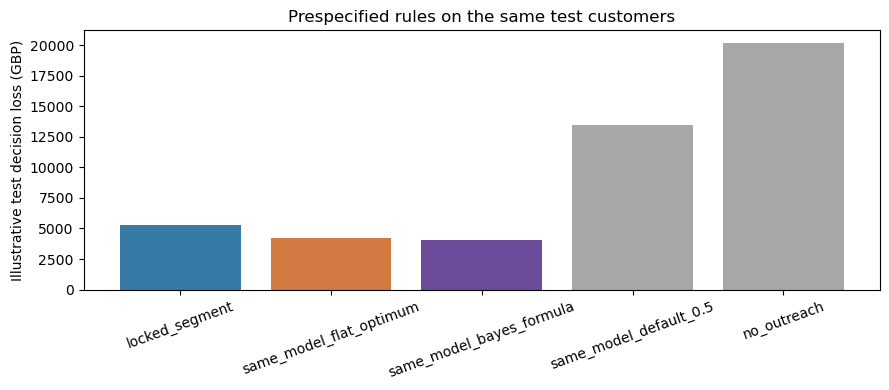

In [22]:
view = test_results.set_index("policy").loc[
    ["locked_segment", "same_model_flat_optimum", "same_model_bayes_formula",
     "same_model_default_0.5", "no_outreach"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(view.index, view["decision_loss"],
      color=["#367ba5", "#d17a42", "#6b4c9a", "#a7a7a7", "#a7a7a7"])
ax.set(ylabel="Illustrative test decision loss (GBP)", title="Prespecified rules on the same test customers")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the held-out chart.** All three low-threshold rules beat a default 0.5
cutoff and beat doing nothing, by a wide margin -- the core case for a low threshold
under this cost structure (missing an actual churner is expensive; a false positive is
cheap) holds up on test regardless of exactly how that low threshold was chosen. Among
the three, the closed-form formula (purple) scores lowest, then the flat-optimum sweep,
then the locked segment-optimal rule -- the reverse of their validation ordering. That's
a held-out *observation*, not a basis for promoting any of them: doing so would require
a new prospective validation, not a retroactive swap based on the one test set they're
all being compared against.

## 7. Save the frozen selection and decision audit

In [23]:
policy = {
    "model": MODEL, "threshold": THRESHOLD, "cost_basis": "segment",
    "selection_population": "validation", "evaluation_population": "test",
    "validation_n": len(validation), "test_n": len(test),
    "flat_fp_cost_assumed": 15, "margin_assumed": 0.25,
    "status": "illustrative_decision_proxy",
}
with (PROCESSED_DATA / "retail_locked_policy.json").open("w") as f:
    json.dump(policy, f, indent=2)

choice_table.to_parquet(PROCESSED_DATA / "retail_validation_policy_comparison.parquet", index=False)
test_results.to_parquet(PROCESSED_DATA / "retail_test_policy_comparison.parquet", index=False)
test_decisions.to_parquet(PROCESSED_DATA / "retail_test_decisions.parquet", index=False)
print("Saved validation comparison, locked policy, one-time test comparison, and decisions")

Saved validation comparison, locked policy, one-time test comparison, and decisions


### Summary

- **A closed-form check (Oliveira's `t* = FP/(FP+FN)`) lands close to the swept
  optimum on validation** (£75-82 above the true minimum, ~2-3%) -- consistent with
  notebook 4's decision to skip SMOTE and `class_weight="balanced"`, and a much smaller
  gap than the source article found on its own SMOTE-affected data. On test, the
  formula threshold actually scores lowest of all three real candidates -- a genuine,
  slightly surprising result, kept as an observation rather than a reason to swap the
  locked rule.
- **Locked rule: Gradient Boosting at threshold 0.09**, selected on validation
  under segment-aware costs -- lower loss than the same model's flat-cost-optimal
  threshold (0.06) once both are scored under segment prices.
- **Loyal Customers drive the largest share of validation loss (43%)**, from false
  positive volume rather than the highest unit price -- Champions and Churn Risk (high
  value) are priced higher per action but have far fewer false positives.
- **The optimal choice is genuinely sensitive to the margin and price assumptions**:
  only 3 of 9 plausible scenarios pick GBC @ 0.09. This is a property of the
  illustrative-assumption design, not a bug.
- **On test, a prespecified flat-optimum comparator (0.06) actually scores lower**
  than the locked rule -- a real, useful held-out observation, fully traceable to 24
  customers whose flag changes between the two thresholds. It does not change which
  rule stays locked.
- Both open items carried forward from the first iteration are addressed here: the
  threshold is now selected on a held-out validation set, separate from the test set
  it's ultimately checked against, and segment-aware pricing is tested (and shown to
  change the optimal threshold) rather than left unexplored.

**Next:** `06_Intervention_Design.ipynb` -- convert the locked rule into a reviewable
customer-level action plan, audit who it flags, and design the prospective experiment
that would actually test whether any of this works.